### Important Notes
* Make sure to install unite with the editable flag.
* If you want 64-bit precision in JAX, you need to set the relevant environment variable: "JAX_ENABLE_X64" = "1"

In [1]:
import os, sys, numpy, scipy, json
from astropy.table import Table
os.environ['JAX_ENABLE_X64'] = '1' 
from unite.spectra import NIRSpecSpectra
from unite.fitting import NIRSpecFit 
from unite.utils import download_spectra
from dotfit import EmissionLines
import jax, jaxlib

print(sys.version)
print("numpy:", numpy.__version__)
print("scipy:", scipy.__version__)
print("jax:", jax.__version__)
print("jaxlib:", jaxlib.__version__)
print("jax x64 enabled:", jax.numpy.ones(1).dtype == jax.numpy.float64)
print("Available backends:", jax.devices())
print('Emission loaded successfully:',len(EmissionLines().get_multiplet('[FeII]-9952')) == 2)

3.13.11 | packaged by conda-forge | (main, Dec  6 2025, 11:28:54) [Clang 19.1.7 ]
numpy: 2.3.5
scipy: 1.16.3
jax: 0.5.0
jaxlib: 0.5.0
jax x64 enabled: True
Available backends: [CpuDevice(id=0)]
Emission loaded successfully: True


Here is an example of running the code to fit two dispersers for a single spectrum. You create the table of the sources and ensure that they get loaded in correctly. To make sure different dispersers are processed together they must share the same root and srcid. 

In [2]:
from pathlib import Path
spec_dir = 'spectra'
out_dir = 'out'
table_csv = '8204.csv'

spec_names = [
    'abell2744-greene-v4_g235m-f170lp_8204_45924.spec.fits',
#    'abell2744-greene-v4_g395m-f290lp_8204_45924.spec.fits',
#    'abell2744-greene-v4_prism-clear_8204_45924.spec.fits',
]

spec_table = download_spectra(
    spec_names,
    table_csv=table_csv,
    spectra_directory=spec_dir,   # where to place the file
)

spectra = NIRSpecSpectra(rows=spec_table)

# check to see what this table looks like
spec_table['srcid','file','root','grating','grade','z','spectra_directory']

srcid,file,root,grating,grade,z,spectra_directory
int64,str53,str19,str5,int64,float64,str7
45924,abell2744-greene-v4_g235m-f170lp_8204_45924.spec.fits,abell2744-greene-v4,G235M,3,4.4633,spectra


Now that we know how to load in the data, we can set up the fit itself. The emission lines (and their line types) that we want to fit need to be specified in a configuration file. 
Here you can also specify absorption or cauchy components. 

In [3]:
from logging import config
from dotfit import EmissionLines
from unite import defaults    
import numpy as np
el = EmissionLines()
sigut = EmissionLines('feii_sigut03.csv')
s='/Users/ivo/Astro/PROJECTS/UNCOVER/sci/deep/dotfit/dotfit/data/emission_lines'
sigut.table = Table.read(s+'/feii_sigut03.csv')
el.add_lines(sigut.get_table('Fe II',wave=[3100,3700]))
el.add_lines(sigut.get_table('Fe II',wave=[7100,11000]))
ku = EmissionLines('feii_opt_kurucz.csv')
ku.table = Table.read('feii_opt_kurucz.csv')
el.add_lines(ku.get_table('Fe II',wave=[3700,7100]))

#ab = EmissionLines('feti_kurucz.csv')
#el.add_lines(ab.get_table('Fe II',wave=[4200,4800]))
# get tid of line_ratio_method
# explore lines like so
# el.get_table('[Fe II]',wave=[4000,4100])
# el.get_table(wave=[4000,4200])
# el.get_table('He I')
# el.get_multiplet('[FeII]-4418')

name = 'monster'
sel = Table.read('monster_v2.csv')
sel.sort('wave_vac')

def lines_NeIII():
    groups = [{'name': 'NeIII_gaussian'}]
    groups.append({'absorption': 'H7'}) 
    groups.append({'emission': '[OII],H7,H8,[NeIII]-3870'})
#    groups.append({'emission': '[OII], H7,H8,H9,H10,H11,H12,H13'})
#    groups.append({'emission': '[NeIII]-3870'})
    groups.append({'outflow': '[NeIII]-3870'})
#    groups.append({'emission': 'HeI-3821'}) #HeI-3873,HeI-3890
#    groups.append({'narrow': 'CaII-3935'}) 
    #groups.append({'narrow': 'CaII-3935*'}) 
    config = el.to_unite(groups, save=True)
    # config['continuum'] = {
    #     'type': 'blackbody',
    #     'temperature': (3_000, 10_000),  # Kelvin
    # }   
    # config["continuum"] = {"type": "modified_blackbody",
    #                       "temperature": (3_000, 10_000),
    #                       "beta": (-2.0, 2.0)
    #                      }
    # config['continuum'] = {'type': 'attenuated_blackbody', 
    #                 'temperature': (3_000.0, 10_000.0), 
    #                 'tau_v': (-0.1, 0.1), 
    #                 'alpha': (-1.8, -1.7) # steep, smc like
    #                 }
    return config

def lines_NeIII_dev():
    groups = [{'name': 'NeIII_dev'}]
    groups.append({'absorption': 'H7, H8, H9, H10, H11'}) 
    groups.append({'emission': '[OII]-3727, H7'})
    groups.append({'emission': '[NeIII]-3870', 'additional':'broad', 'TieRedshift':False})
    groups.append({'emission': 'HeI-3821'}) #HeI-3873,HeI-3890
    groups.append({'narrow': 'CaII-3935'}) 
    config = el.to_unite(groups, save=True)    
    return config

def lines_UV():
    groups = [{'name': f'{name}_UV'}]

    iuv = np.where((sel['wave_vac'] < 3650))[0][0:3]
    fb = ','.join([m['key']+'*' for m in sel[iuv] if '[' in m['key']])
    pe = ','.join([m['key']+'*' for m in sel[iuv] if '[' not in m['key']])
    groups.append({'emission': pe})
    groups.append({'emission': fb})
    print(pe,fb)
    return el.to_unite(groups, save=True, line_ratio_min = 0.01)


def lines_Hg():
    # -------------------------------------- Hg, Hd
    groups = [{'name': 'Hb+FeII'}]
    groups.append({'absorption': 'Ha, Hb'}) 
    groups.append({'emission': 'Ha, Hb','additional':'exponential'})
#    groups.append({'emission': 'Ha,Hb,[OIII]-5008*', 'additional':'exponential'}) 
    groups.append({'emission': '[OIII]-5008*,[NeIII]-3870', 'additional': 'outflow'})
#    groups.append({'emission': '[NeIII]-3870*,[OIII]-5008*','additional':'outflow'})
 #   groups.append({'emission': 'HeI-4027, HeI-4145, HeI-4389, HeI-4473'})
 #   groups.append({'emission': '[NeIII]-3870*,[OIII]-4364,[SII]-4070,[OIII]-5008*','additional':'outflow'})
#    append * to transition name to include all multiplet lines
#    groups.append({'emission': '[FeII]-4081*,[FeII]-4245*,[FeII]-4289*,[FeII]-4418*'})
#    groups.append({'emission': '[FeII]-4289'})
#    groups.append({'emission': '[FeII]-4597*'})
#    groups.append({'emission': '[FeII]-5159*'})
#    groups.append({'absorption': 'FeII-4597*'})
    config = el.to_unite(groups, save=True)
#    groups.append({'continuum': {'type': 'attenuated_blackbody'}})
    # config['continuum'] = {'type': 'attenuated_blackbody', 
    #                 'temperature': (3_000.0, 10_000.0), 
    #                 'tau_v': (0.0, 0.01), 
    #                 'alpha_atten': (-1.8, -1.4) # steep, smc like
    #                 }
    return config


#groups[0]['name'] = groups[0]['name'].replace('gaussian','exponential')
#groups[2]['additional']='exponential'
#config = el.to_unite(groups, save=True)

# -------------------------------------- Hb+[OIII]
# restrict fit to 4620-5060 A
def lines_Hb():
    groups = [{'name': 'Hb+OIII'}]
    groups.append({'absorption': 'Hb'}) 
    groups.append({'emission': 'Hb', 'additional':'broad'})
    # use [NeIII] to anchor the outflow
#    groups.append({'emission': '[OIII]-5008*', 'additional':'broad'})
    groups.append({'emission': '[OIII]-5008*,[NeIII]-3870', 'additional': 'outflow'})
    # groups.append({'emission': 'HeII-4687'})  
    # groups.append({'emission': 'HeI-4714,HeI-4923,HeI-5017'}) #HeI-3873,HeI-3890
    # groups.append({'emission': '[FeII]-4729,[FeII]-4816'})
    # # worse WAIC [FeII]-5050, [FeII]-4900, [FeII]-4967, HeI-5049
    config = el.to_unite(groups, save=True)
#    config["continuum"] = {"type": "linear"} 
    config['continuum'] = {
        'type': 'blackbody',
        'temperature': (4000, 10000),  # Kelvin
    }
    return config
# defaults.fwhm['absorption'] = (0,750)
# defaults.flux['outflow'] = (0,2)

# groups[0]['name'] = groups[0]['name'].replace('gaussian','exponential')
# groups[2]['additional']='exponential'
# config = el.to_unite(groups, save=True)

def lines_HeI_5877():
    groups = [{'name': 'HeI_5877'}]
#    groups = [{'name': '5500_gaussian', 'region':(5030,6300)}]
    #groups.append({'emission': '[OIII]-5008','multiplet':False})
    groups.append({'emission': '[FeII]-5159,[FeII]-5160,[FeII]-5749'}) #,[FeII]-5903,[FeII]-5984'}) 
    groups.append({'emission': 'HeI-5877', 'additional':'broad'}) #HeI-3873,HeI-3890
    #groups.append({'emission': 'OI-6048'})
    groups.append({'emission': '[NII]-5756'})
    config = el.to_unite(groups, save=True)
    return config

#NaI-5892
#groups[0]['name'] = groups[0]['name'].replace('gaussian','lorentzian')
# groups[2]['additional']='lorentzian'
# config = el.to_unite(groups, save=True)
# defaults.fwhm['absorption'] = (0,750)
#el.get_multiplet('[FeII]-4418')
#ab.get_table('Fe II',wave=[4500,4600])
#el.get_multiplet('FeII-4597')
#el.table[0]
#el.get_table('[Ne III]')
#el.get_table('Fe II', wave=[4550,4580])

#from dotfit.emission_lines import plot_lines
#tab = el.get_table('Fe II', wave=[4400,4700])
#el.plot_lines(wave=[4400,4650],legend=True,per_multiplet_normalize=True)
#plot_lines(tab, wave=[4400,4650],legend=True,per_multiplet_normalize=False, fwhm_kms=2000)

# need strict limits on absorption to avoid
# degenerate solutions. Should probably tie to Hb
defaults.redshift['absorption'] = (-1*defaults.δz, 1*defaults.δz)
#defaults.fwhm['absorption'] = (10,200)
#defaults.flux['absorption'] = (-1,0)
#defaults.flux['narrow'] = (-2,2)
#defaults.fwhm['narrow'] = (0,400)
defaults.redshift['outflow'] = (-1*defaults.δz, 0.1*defaults.δz)
defaults.flux['outflow'] = (0,2)

config = lines_NeIII()
#config = lines_UV()
config = lines_Hg()
#config = lines_Hb()
#config = lines_HeI_5877()

config


name NeIII_gaussian
name Hb+FeII


{'Name': 'Hb+FeII',
 'Unit': 'Angstrom',
 'Groups': {'absorption1': {'TieRedshift': True,
   'TieDispersion': True,
   'Species': [{'Name': 'HI',
     'LineType': 'absorption',
     'Lines': [{'Wavelength': 6564.632, 'RelStrength': None},
      {'Wavelength': 4862.691, 'RelStrength': None}]}]},
  'emission1': {'TieRedshift': True,
   'TieDispersion': True,
   'Species': [{'Name': 'HI',
     'LineType': 'emission',
     'AdditionalComponents': {'exponential': 'emission1'},
     'Lines': [{'Wavelength': 6564.632, 'RelStrength': None},
      {'Wavelength': 4862.691, 'RelStrength': None}]}]},
  'emission2': {'TieRedshift': True,
   'TieDispersion': True,
   'Species': [{'Name': '[NeIII]',
     'LineType': 'emission',
     'AdditionalComponents': {'outflow': 'emission2'},
     'Lines': [{'Wavelength': 3869.86, 'RelStrength': None}]},
    {'Name': '[OIII]m1',
     'LineType': 'emission',
     'AdditionalComponents': {'outflow': 'emission2'},
     'Lines': [{'Wavelength': 4960.295, 'RelStreng

Running the fit is now easy! We use MCMC sampling as implemented in numpyro NUTS. Let's use 500 samples for warm-up, and 1000 for the actual sampling.

The fitting produces some files that store the full chains and a summary of results, and also a figure showing the fit. You can choose the location where to store these files.

In [4]:
# from unite.initial import computeContinuumRegions

# # Load spectra to compute regions
# cont_regs, cont_guesses = computeContinuumRegions(config, spectra)
# cont_regs, cont_guesses

In [ ]:
config['continuum'] = {'type': 'blackbody', 'temperature': (4000, 10000)}
config["continuum"] = {
    "type": "modified_blackbody",
    "temperature": (3_000, 10_000),
    "beta": (-2.0, 2.0),       # spectral index bounds
}
# attenuated BB
config['continuum'] = {'type': 'attenuated_blackbody',
                         'temperature': (4000, 10000),
                         'tau_v': (0.0, 2.0),       # optical depth
                         'alpha': (-2.5, -2.3)}       # extinction slope
config['continuum'] = {'type': 'none'}
config['fitting_mode'] = 'lines'  # override the auto-inferred 'full'
#config['fitting_mode'] = 'full'  # override the auto-inferred 'full'
#config['fitting_mode'] = 'continuum'  # override the auto-inferred 'full'

# modified defaults
defaults.δz = 0.001
defaults.CONTINUUM = defaults.LINEPAD*5
N=100
results = NIRSpecFit(config, spec_table, spectra, out_dir, N=N, num_warmup=N, rescale_errors=False)

ValueError: 'none' is not a valid FittingMode

In [10]:
results.summary()

AttributeError: 'NoneType' object has no attribute 'summary'

In [ ]:
import importlib
import unite.plotting
importlib.reload(unite.plotting)
importlib.reload(sys.modules['unite.fitting'])
from unite.plotting import plotResults, plotRegionSingle

# recreate the output plots with other plotting options
plot_kw={"yscale": "linear","ylim":[0,40],'show_lines':True} 

# data contains the samples, components, best model index, and spectra information
fig, data = plotResults(config, rows=spec_table, output_dir=out_dir, plot_kwargs=plot_kw)
fig


In [ ]:
# el = EmissionLines('feti_kurucz.csv')
# tab = el.get_table('Fe II',wave=[3700,6500])
# tab.write('feii_opt_kurucz.csv'

KeyError: 'continuum'

(0.0, 20.0)

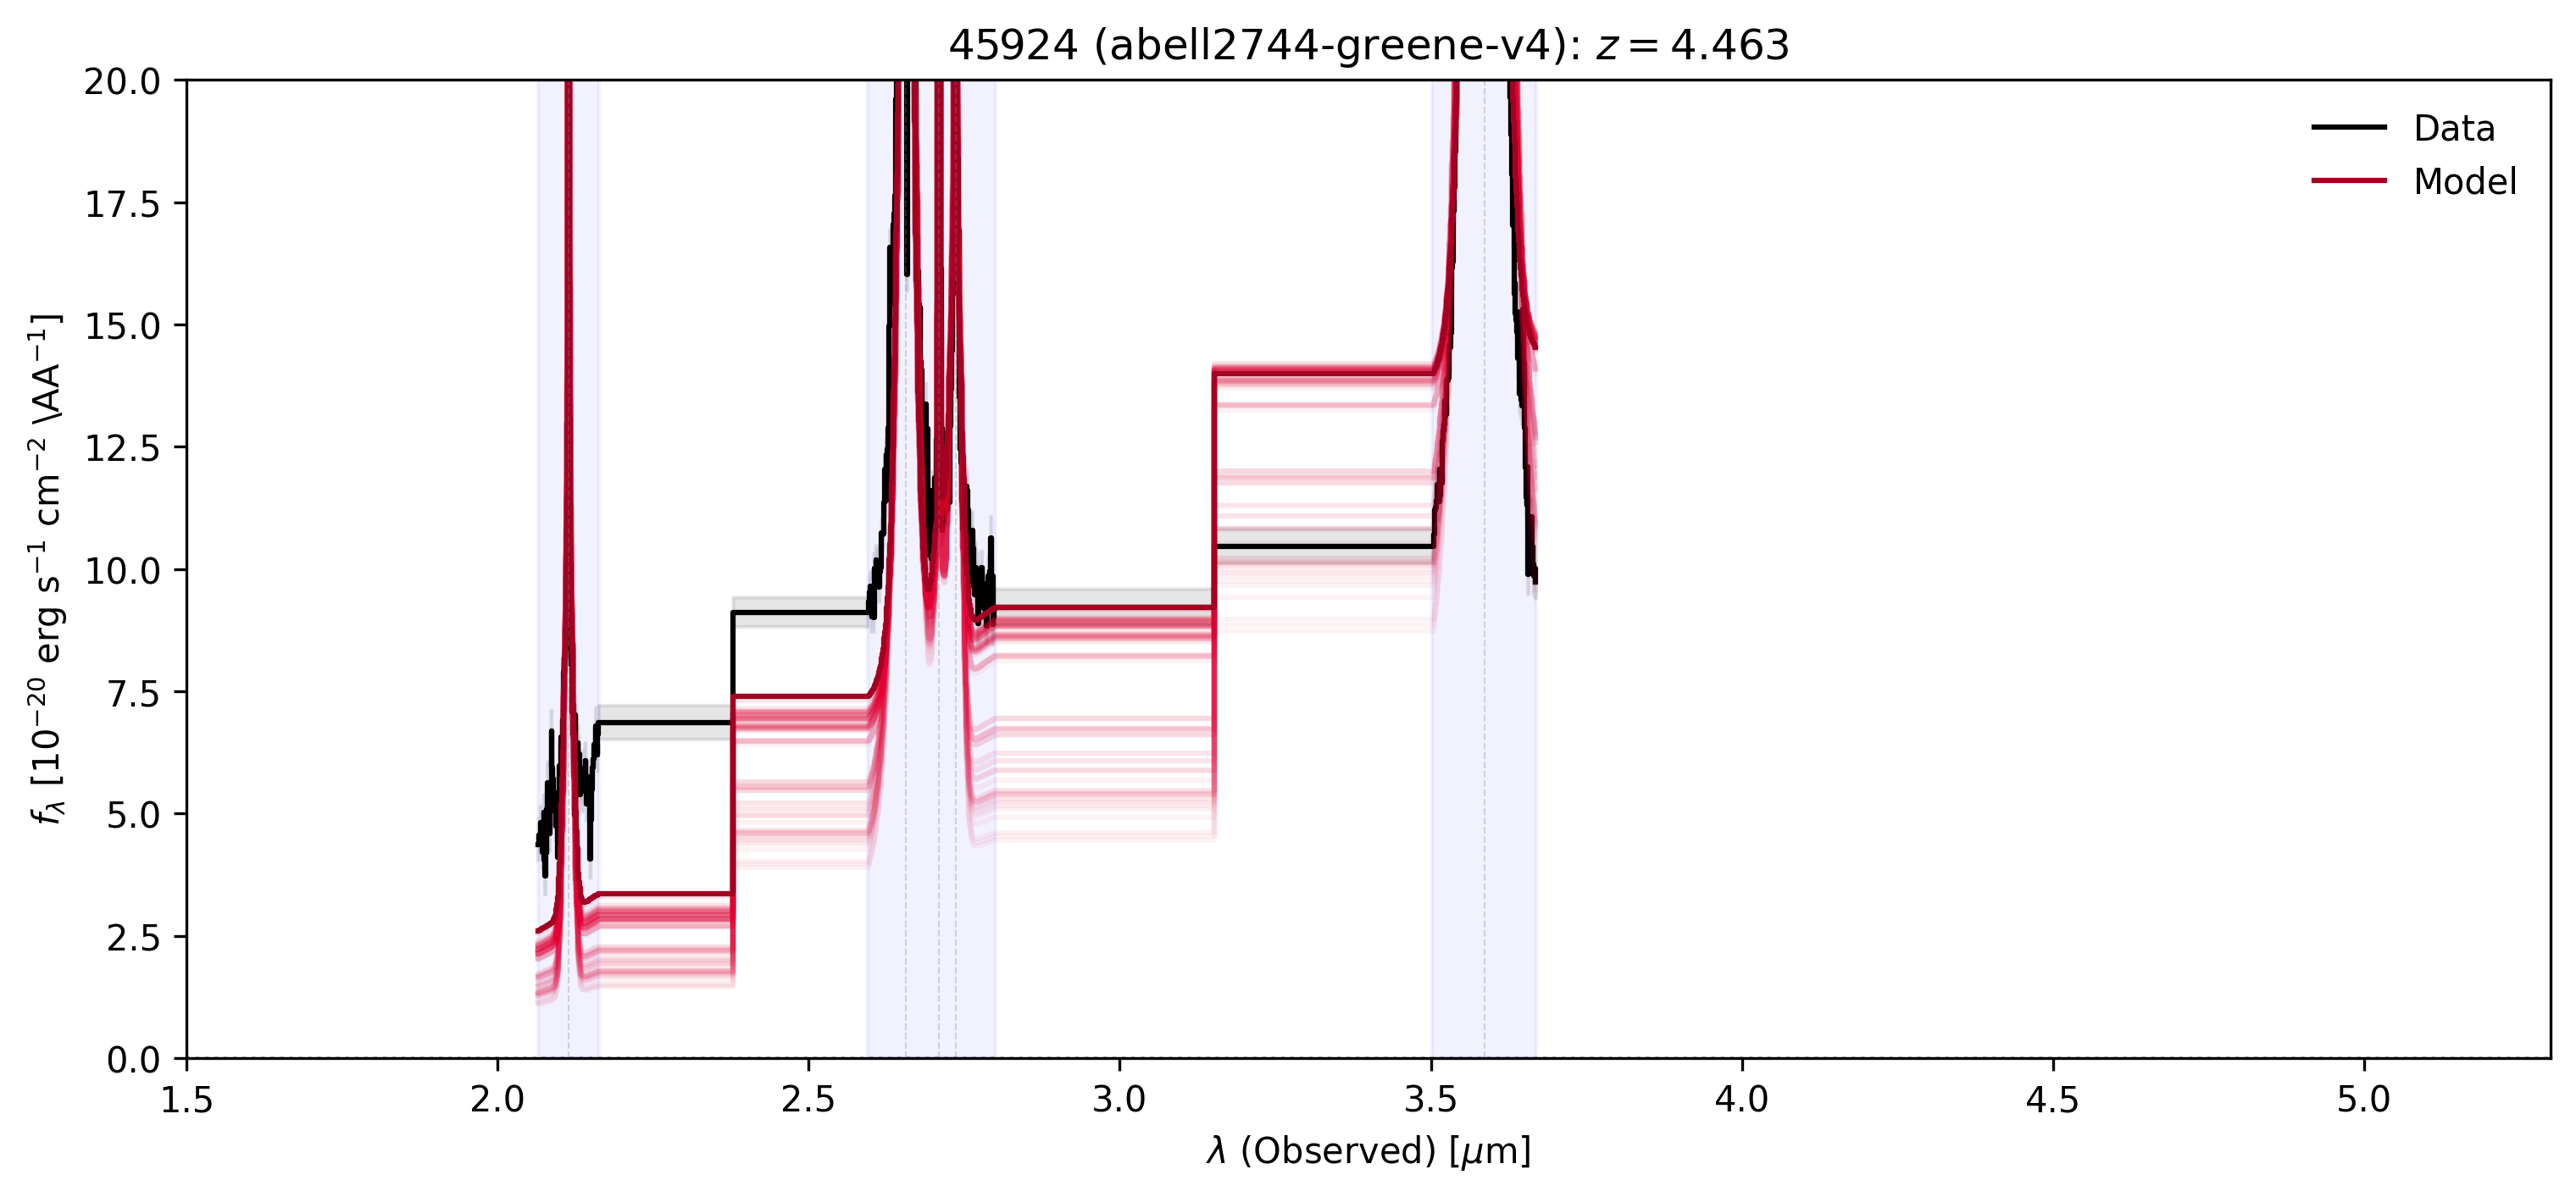

In [17]:
from unite.plotting import plotFullSpectrum
fig, ax = plotFullSpectrum(
    config=config,
    rows=spec_table,  # Use suite.rows, NOT spec_table_val!
    output_dir='out',
    wavelength_range=(1.7, 3.8),  # Optional: zoom to range
)
ax.set_xlim(1.5,5.3)
ax.set_ylim(0.,20.)